In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score



In [2]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df_def = pd.read_parquet('../data/lgd_dataset.parquet')
# Limpiar term antes de todo el código
df_def['term'] = df_def['term'].str.strip()

# ── 1. LGD por segmento ──────────────────────────────────────

# Nivel 1: grade x term (segmentación principal)
lgd_grade_term = (df_def
    .groupby(['grade', 'term'])['lgd']
    .agg(['mean', 'std', 'count', 'median'])
    .round(4)
    .reset_index())
lgd_grade_term.columns = ['grade', 'term', 'lgd_mean', 'lgd_std', 'n', 'lgd_median']

print("=== LGD por Grade x Term ===")
print(lgd_grade_term.to_string(index=False))

# Nivel 2: solo grade (fallback si poco volumen)
lgd_grade = (df_def
    .groupby('grade')['lgd']
    .agg(['mean', 'std', 'count'])
    .round(4)
    .reset_index())
lgd_grade.columns = ['grade', 'lgd_mean', 'lgd_std', 'n']

print("\n=== LGD por Grade ===")
print(lgd_grade.to_string(index=False))

# LGD global (fallback final)
lgd_global = df_def['lgd'].mean()
print(f"\nLGD global: {lgd_global:.4f}")

=== LGD por Grade x Term ===
grade      term  lgd_mean  lgd_std     n  lgd_median
    A 36 months    0.9430   0.0998  5900      0.9878
    A 60 months    0.9507   0.1195   307      1.0000
    B 36 months    0.9396   0.0854 19147      0.9597
    B 60 months    0.9411   0.0959  3884      0.9978
    C 36 months    0.9332   0.0883 24394      0.9478
    C 60 months    0.9310   0.0869 13035      0.9428
    D 36 months    0.9298   0.0945 14473      0.9475
    D 60 months    0.9248   0.0934 11858      0.9355
    E 36 months    0.9252   0.0995  5059      0.9460
    E 60 months    0.9151   0.0985 10226      0.9197
    F 36 months    0.9185   0.1077  1180      0.9400
    F 60 months    0.9087   0.1041  4933      0.9106
    G 36 months    0.9167   0.1121   323      0.9353
    G 60 months    0.9062   0.0996  1596      0.9034

=== LGD por Grade ===
grade  lgd_mean  lgd_std     n
    A    0.9434   0.1008  6207
    B    0.9398   0.0873 23031
    C    0.9325   0.0878 37429
    D    0.9276   0.0940 2633

In [3]:
# ── 2. Asignar LGD estimada a cada préstamo ──────────────────

df_def = df_def.merge(
    lgd_grade_term[['grade', 'term', 'lgd_mean']].rename(
        columns={'lgd_mean': 'lgd_estimated'}),
    on=['grade', 'term'],
    how='left'
)

# Fallback a grade si no hay combinación grade x term
lgd_grade_map = lgd_grade.set_index('grade')['lgd_mean'].to_dict()
mask_null = df_def['lgd_estimated'].isna()
df_def.loc[mask_null, 'lgd_estimated'] = df_def.loc[mask_null, 'grade'].map(lgd_grade_map)

# Fallback global
df_def['lgd_estimated'] = df_def['lgd_estimated'].fillna(lgd_global)

print(f"\nNulos en lgd_estimated: {df_def['lgd_estimated'].isna().sum()}")


Nulos en lgd_estimated: 0


In [4]:
# Split temporal consistente con Semana 2
df_def['issue_d_dt'] = pd.to_datetime(df_def['issue_d'], format='%b-%Y', errors='coerce')
cutoff = pd.Timestamp('2016-01-01')
test_mask = df_def['issue_d_dt'] >= cutoff

lgd_actual = df_def.loc[test_mask, 'lgd']
lgd_pred   = df_def.loc[test_mask, 'lgd_estimated']

mae = mean_absolute_error(lgd_actual, lgd_pred)
r2  = r2_score(lgd_actual, lgd_pred)

print(f"\n=== Evaluación en test (post-2016) ===")
print(f"MAE:            {mae:.4f}")
print(f"R²:             {r2:.4f}")
print(f"LGD pred media: {lgd_pred.mean():.4f}")
print(f"LGD real media: {lgd_actual.mean():.4f}")


=== Evaluación en test (post-2016) ===
MAE:            0.0649
R²:             -0.0032
LGD pred media: 0.9307
LGD real media: 0.9396


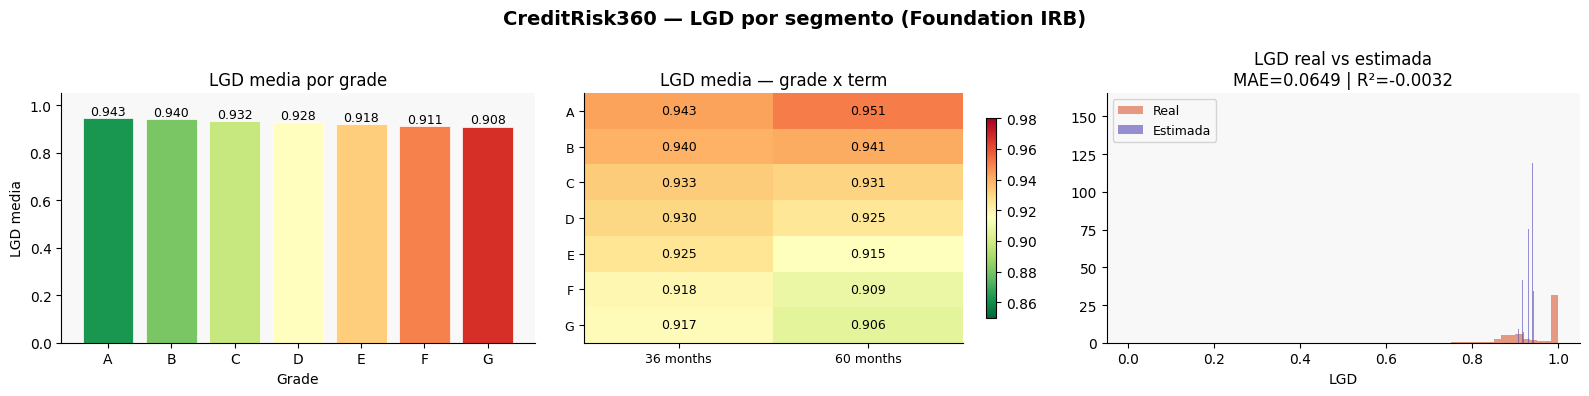

In [5]:
# ── 4. Visualización ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CreditRisk360 — LGD por segmento (Foundation IRB)', 
             fontsize=14, fontweight='bold')

# 4.1 LGD media por grade
ax = axes[0]
grades = lgd_grade.sort_values('grade')
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grades)))
bars = ax.bar(grades['grade'], grades['lgd_mean'], color=colors,
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, grades['lgd_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('LGD media por grade')
ax.set_xlabel('Grade')
ax.set_ylabel('LGD media')
ax.set_ylim(0, 1.05)
# 4.2 LGD media por grade x term (heatmap simple)
ax = axes[1]
pivot = lgd_grade_term.pivot(index='grade', columns='term', values='lgd_mean')
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0.85, vmax=0.98)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9)
ax.set_title('LGD media — grade x term')
plt.colorbar(im, ax=ax, shrink=0.8)

# 4.3 Distribución real vs estimada en test
ax = axes[2]
ax.hist(lgd_actual, bins=60, alpha=0.6, color='#D85A30',
        label='Real', density=True)
ax.hist(lgd_pred, bins=30, alpha=0.6, color='#534AB7',
        label='Estimada', density=True)
ax.set_title(f'LGD real vs estimada\nMAE={mae:.4f} | R²={r2:.4f}')
ax.set_xlabel('LGD')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/06b_lgd_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── 5. Guardar tabla LGD y predicciones ─────────────────────

lgd_grade_term.to_csv('../data/lgd_table_grade_term.csv', index=False)
lgd_grade.to_csv('../data/lgd_table_grade.csv', index=False)

# Predicciones para Notebook 08 (Expected Loss)
df_lgd_preds = pd.DataFrame({
    'lgd_estimated': lgd_pred,
    'lgd_actual':    lgd_actual
})
df_lgd_preds.to_parquet('../data/lgd_predictions.parquet')

print("\nArchivos guardados:")
print("  data/lgd_table_grade_term.csv")
print("  data/lgd_table_grade.csv")
print("  data/lgd_predictions.parquet")


Archivos guardados:
  data/lgd_table_grade_term.csv
  data/lgd_table_grade.csv
  data/lgd_predictions.parquet


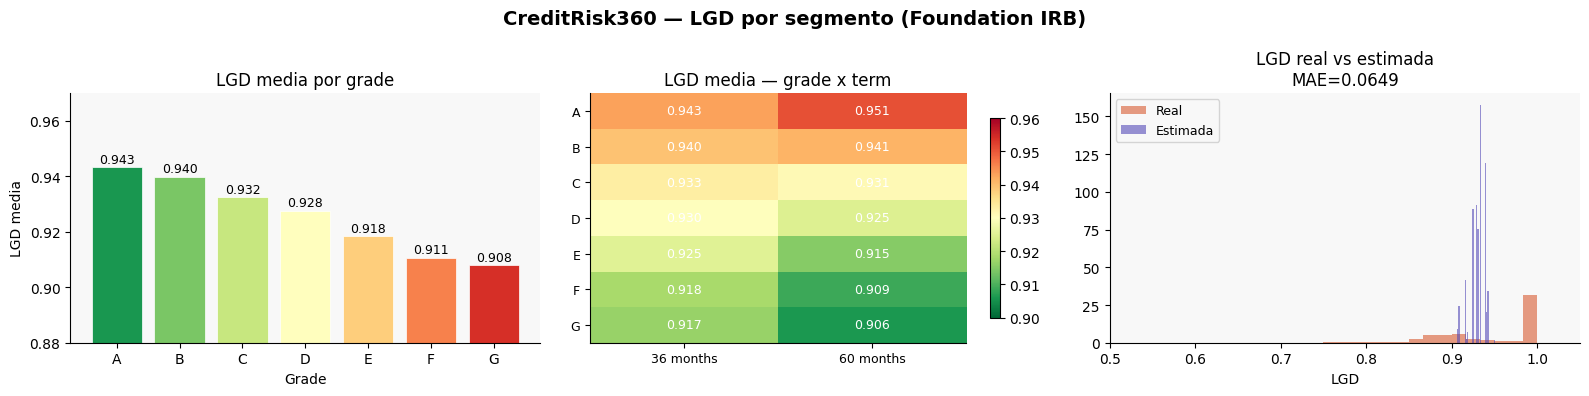

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CreditRisk360 — LGD por segmento (Foundation IRB)',
             fontsize=14, fontweight='bold')

# 4.1 LGD media por grade
ax = axes[0]
grades = lgd_grade.sort_values('grade')
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grades)))
bars = ax.bar(grades['grade'], grades['lgd_mean'], color=colors,
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, grades['lgd_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('LGD media por grade')
ax.set_xlabel('Grade')
ax.set_ylabel('LGD media')
ax.set_ylim(0.88, 0.97)  # zoom donde está la variación real

# 4.2 Heatmap grade x term
ax = axes[1]
pivot = lgd_grade_term.pivot(index='grade', columns='term', values='lgd_mean')
pivot.columns = [c.strip() for c in pivot.columns]  # limpiar espacios
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0.90, vmax=0.96)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color='white')
ax.set_title('LGD media — grade x term')
plt.colorbar(im, ax=ax, shrink=0.8)

# 4.3 Distribución real vs estimada
ax = axes[2]
ax.hist(lgd_actual.values, bins=60, alpha=0.6, color='#D85A30',
        label='Real', density=True)
ax.hist(lgd_pred.values, bins=30, alpha=0.6, color='#534AB7',
        label='Estimada', density=True)
ax.set_xlim(0.5, 1.05)
ax.set_title(f'LGD real vs estimada\nMAE={mae:.4f}')
ax.set_xlabel('LGD')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/06b_lgd_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
df_def = pd.read_parquet('../data/lgd_dataset.parquet')
print(df_def[['funded_amnt', 'out_prncp', 'total_rec_prncp']].describe().round(2))
print(f"\nout_prncp == 0: {(df_def['out_prncp'] == 0).mean()*100:.1f}%")

       funded_amnt  out_prncp  total_rec_prncp
count    116315.00  116315.00        116315.00
mean      15642.39     839.83          4481.53
std        8886.52    3771.31          4239.10
min         500.00       0.00             0.00
25%        9000.00       0.00          1547.70
50%       14400.00       0.00          3202.65
75%       20700.00       0.00          5992.49
max       40000.00   40000.00         35015.76

out_prncp == 0: 92.6%


In [10]:
df_def['ead'] = (df_def['funded_amnt'] - df_def['total_rec_prncp']).clip(lower=0)
print(df_def['ead'].describe().round(2))
print(f"\nEAD media / funded_amnt media: {df_def['ead'].mean() / df_def['funded_amnt'].mean():.3f}")
print(f"EAD == 0: {(df_def['ead'] == 0).mean()*100:.1f}%")

count    116315.00
mean      11160.86
std        7809.69
min           0.00
25%        4979.16
50%        9457.04
75%       15593.36
max       40000.00
Name: ead, dtype: float64

EAD media / funded_amnt media: 0.714
EAD == 0: 0.0%
